# Vanilla HNSW

In [1]:
import struct
import numpy as np
import torch
import torch.nn.functional as F
import heapq
from tqdm import tqdm

def read_fvecs(path: str) -> np.ndarray:
    """Read .fvecs file into (N, d) float32 array."""
    with open(path, 'rb') as f:
        vecs = []
        while True:
            hdr = f.read(4)
            if not hdr:
                break
            d = struct.unpack('i', hdr)[0]
            data = struct.unpack('f' * d, f.read(4 * d))
            vecs.append(data)
    return np.vstack(vecs).astype('float32')


def read_ivecs(path: str) -> np.ndarray:
    """Read .ivecs file into (N, k) int array."""
    with open(path, 'rb') as f:
        idxs = []
        while True:
            hdr = f.read(4)
            if not hdr:
                break
            k = struct.unpack('i', hdr)[0]
            data = struct.unpack('i' * k, f.read(4 * k))
            idxs.append(data)
    return np.vstack(idxs).astype('int64')

# ----------------------------
# Select GPU or CPU
# ----------------------------
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
display(device)

device(type='cpu')

In [2]:
class HNSWIndex:
    """
    Exact Python implementation of Hierarchical NSW (HNSW) per Malkov & Yashunin.

    Parameters
    ----------
    M : int
        Maximum number of connections per node on layers > 0.
    M0 : int
        Maximum number of connections per node on layer 0 (ground layer).
    ef_construction : int
        Size of the dynamic candidate list during index construction.
    ef_search : int
        Size of the dynamic candidate list during K-NN queries.
    mL : float
        Level generation decay constant (typical default 1 / ln(M)).
    metric : {'l2', 'cosine'}
        Distance metric to use.
    extend_candidates : bool
        Whether to extend candidate set by neighbors of candidates in SELECT-NEIGHBORS.
    keep_pruned : bool
        Whether to fill up pruned slots from discarded candidates in SELECT-NEIGHBORS.
    """
    def __init__(self, M=16, M0=None, ef_construction=200, ef_search=200,
                 mL=None, metric='l2', extend_candidates=False, keep_pruned=False):
        self.M = M
        self.M0 = M0 if M0 is not None else 2 * M
        self.ef_construction = ef_construction
        self.ef_search = ef_search
        self.mL = mL if mL is not None else (1.0 / np.log(M))
        self.metric = metric
        self.extend_candidates = extend_candidates
        self.keep_pruned = keep_pruned

        self.data = None
        self.levels = []        # list of dicts: each {'nodes': [idx], 'nbrs': {idx: [nbrs]}}
        self.level_assign = None  # array of shape (N,) with level for each element
        self.max_level = -1
        self.entry_point = -1

    def _dist(self, a, b):
        """Compute distance between two vectors a, b."""
        if self.metric == 'l2':
            return np.linalg.norm(a - b)
        # cosine distance = 1 - cosine similarity
        return 1.0 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

    def fit(self, data):
        """
        Build the HNSW index from the given data matrix.
        Parameters
        ----------
        data : array_like, shape (N, d)
            Input vectors.
        """
        self.data = np.asarray(data, dtype=np.float32)
        N, d = self.data.shape

        # Normalize if using cosine
        if self.metric == 'cosine':
            norms = np.linalg.norm(self.data, axis=1, keepdims=True)
            self.data = self.data / norms

        # 1) Generate random levels per element
        rnd = np.random.rand(N)
        levels = np.floor(-np.log(rnd) * self.mL).astype(int)
        self.level_assign = levels
        self.max_level = -1

        # 2) Initialize layer structures
        maxL = int(levels.max())
        self.levels = [
            {'nodes': [], 'nbrs': {}}
            for _ in range(maxL + 1)
        ]

        current_max = -1

        # 3) Insert each element sequentially
        for idx in tqdm(range(N), desc='Building HNSW'):
            lvl = levels[idx]
            # Update entry point if this has new highest level
            if lvl > current_max:
                current_max = lvl
                self.entry_point = idx
                self.max_level = lvl

            # Top-down search from highest layer to lvl+1 with ef=1
            ep = self.entry_point
            for layer in range(current_max, lvl, -1):
                W = self._search_layer(idx, [ep], ef=1, layer=layer)
                if W:
                    # pick nearest in W to idx
                    ep = min(W, key=lambda e: self._dist(self.data[idx], self.data[e]))

            # Bottom-up insertion: layers min(current_max, lvl) ... 0
            for layer in range(min(current_max, lvl), -1, -1):
                # search to get candidate pool
                W = self._search_layer(idx, [ep], ef=self.ef_construction, layer=layer)

                # select M neighbors from W
                cap = self.M0 if layer == 0 else self.M
                neighbors = self._select_neighbors(idx, W, layer, cap)

                # add node to layer
                L = self.levels[layer]
                L['nodes'].append(idx)
                L['nbrs'][idx] = neighbors.copy()

                # bidirectional links and re-prune existing nodes
                for e in neighbors:
                    L['nbrs'].setdefault(e, []).append(idx)
                    # shrink e's list if too big
                    cap_e = self.M0 if layer == 0 else self.M
                    if len(L['nbrs'][e]) > cap_e:
                        pruned = self._select_neighbors(e, L['nbrs'][e], layer, cap_e)
                        L['nbrs'][e] = pruned

                # set ep = nearest in W to idx for next layer
                if W:
                    ep = min(W, key=lambda e: self._dist(self.data[idx], self.data[e]))

    def _search_layer(self, q_idx, ep_list, ef, layer):
        """
        Algorithm 2: SEARCH-LAYER
        Returns a list of up to ef node indices closest to data[q_idx].
        """
        q = self.data[q_idx]
        L = self.levels[layer]
        visited = set(ep_list)

        # min-heap C of (dist, node)
        C = []
        # max-heap W of (−dist, node) size ≤ ef
        W = []

        # init with entry seeds
        for e in ep_list:
            d = self._dist(q, self.data[e])
            heapq.heappush(C, (d, e))
            heapq.heappush(W, (-d, e))

        while C:
            d_u, u = heapq.heappop(C)
            if len(W) >= ef and d_u > -W[0][0]:
                break  # all closer candidates evaluated
            for v in L['nbrs'].get(u, []):
                if v in visited:
                    continue
                visited.add(v)
                d_v = self._dist(q, self.data[v])
                if len(W) < ef or d_v < -W[0][0]:
                    heapq.heappush(C, (d_v, v))
                    heapq.heappush(W, (-d_v, v))
                    if len(W) > ef:
                        heapq.heappop(W)
        # extract results
        return [node for (_, node) in sorted(W, key=lambda x: -x[0])]

    def _select_neighbors(self, q_idx, candidates, layer, M):
        """
        Algorithm 4: SELECT-NEIGHBORS heuristic
        Inputs:
          q_idx: index of the base element
          candidates: list of node indices
          layer: current layer
          M: number of neighbors to select
        """
        # optionally extend candidate set
        if self.extend_candidates:
            ext = set(candidates)
            for c in candidates:
                ext.update(self.levels[layer]['nbrs'].get(c, []))
            candidates = list(ext)

        # compute distances to q
        cand = [(c, self._dist(self.data[q_idx], self.data[c])) for c in candidates]
        # sort by dist ascending
        cand.sort(key=lambda x: x[1])

        R = []
        Wd = []
        for c, d_qc in cand:
            if len(R) >= M:
                break
            # reject if any already-selected neighbor is closer to c than q is
            if all(self._dist(self.data[c], self.data[r]) >= d_qc for r in R):
                R.append(c)
            else:
                Wd.append(c)
        # fill pruned slots if desired
        if self.keep_pruned and len(R) < M:
            for c in Wd:
                R.append(c)
                if len(R) >= M:
                    break
        return R[:M]

    def search(self, query_vec, k=1):
        """
        Algorithm 5: K-NN SEARCH
        Returns k nearest neighbor indices of the query vector.
        """
        # if cosine, normalize
        if self.metric == 'cosine':
            q = query_vec / np.linalg.norm(query_vec)
        else:
            q = query_vec
        # temporarily append as last idx
        N = len(self.data)
        self.data = np.vstack([self.data, q])
        q_idx = N

        # top-down greedy from entry_point
        ep = self.entry_point
        for layer in range(self.max_level, 0, -1):
            W = self._search_layer(q_idx, [ep], ef=1, layer=layer)
            if W:
                ep = min(W, key=lambda e: self._dist(q, self.data[e]))

        # bottom layer best-first
        W0 = self._search_layer(q_idx, [ep], ef=self.ef_search, layer=0)
        # remove temp q
        self.data = self.data[:-1]

        # return the k closest from W0
        W0.sort(key=lambda e: self._dist(query_vec, self.data[e]))
        return W0[:k]

In [3]:
import time
import numpy as np
import pandas as pd
from tqdm import tqdm

def count_total_edges(idx):
    """
    Count undirected edges across all layers of an HNSWIndex.
    """
    total = 0
    for layer in idx.levels:
        # sum of all adjacency‐list lengths, then undirected => divide by 2
        layer_sum = sum(len(neighs) for neighs in layer['nbrs'].values())
        total += layer_sum // 2
    return total

import torchvision
from torchvision import transforms

tr = torchvision.datasets.MNIST(root='.', train=True, download=True, transform=transforms.ToTensor())
te = torchvision.datasets.MNIST(root='.', train=False, download=True, transform=transforms.ToTensor())

base_full  = np.stack([img.numpy().ravel() for img,_ in tr]).astype('float32')   # (60000,784)
query_full = np.stack([img.numpy().ravel() for img,_ in te]).astype('float32')   # (10000,784)

# Subsample for speed
rng = np.random.default_rng(42)
N_base  = 5000
N_query = 500
b_idx = rng.choice(len(base_full),  size=N_base,  replace=False)
q_idx = rng.choice(len(query_full), size=N_query, replace=False)
base  = base_full[b_idx]
query = query_full[q_idx]

# === 2) Compute exact top-10 ground truth with brute-force in batches ===
def compute_gt(base, query, k=10, batch_size=200):
    nQ = len(query)
    gt = np.empty((nQ, k), dtype=np.int64)
    for i in range(0, nQ, batch_size):
        qb = query[i:i+batch_size]
        dists = np.linalg.norm(qb[:,None,:] - base[None,:,:], axis=2)
        gt[i:i+batch_size] = np.argsort(dists, axis=1)[:,:k]
    return gt

gt2 = compute_gt(base, query, k=10, batch_size=200)

# === 3) Grid settings ===
M_list   = [32, 64]
efc_list = [200, 400]
efs_list = [400, 800, 1600]
reps     = 3

results = []

# === 4) Run grid search on MNIST ===
for M in M_list:
    M0 = 2 * M
    for efc in efc_list:
        for efs in efs_list:
            build_times = []
            avg_qs      = []
            std_qs      = []
            recalls     = []
            std_recs    = []
            edge_counts = []

            for _ in range(reps):
                # instantiate and build
                idx = HNSWIndex(
                    M=M, M0=M0,
                    ef_construction=efc, ef_search=efs,
                    mL=1.0/np.log(M),
                    metric='l2',
                    extend_candidates=False,
                    keep_pruned=False
                )
                t0 = time.time()
                idx.fit(base)
                build_times.append(time.time() - t0)

                # count edges
                edge_counts.append(count_total_edges(idx))

                # query loop
                times, recs = [], []
                for qv, true_nn in zip(query, gt2):
                    tq0 = time.time()
                    pred = idx.search(qv, k=10)
                    times.append((time.time() - tq0) * 1000)
                    recs.append(len(set(pred) & set(true_nn)) / 10)

                avg_qs.append(np.mean(times))
                std_qs.append(np.std(times))
                recalls.append(np.mean(recs))
                std_recs.append(np.std(recs))

            results.append({
                'M': M,
                'ef_construction': efc,
                'ef_search': efs,
                'build_time_s':   float(np.mean(build_times)),
                'avg_query_ms':   float(np.mean(avg_qs)),
                'std_query_ms':   float(np.mean(std_qs)),
                'recall@10':      float(np.mean(recalls)),
                'std_recall':     float(np.mean(std_recs)),
                'num_edges':      int(np.mean(edge_counts))
            })

# === 5) Save and display ===
df = pd.DataFrame(results)
display("MNIST HNSW Grid Search (avg over reps)", df)
df.to_csv("mnist_hnsw_grid_results.csv", index=False)
print("Saved MNIST results to mnist_hnsw_grid_results.csv")

Building HNSW: 100%|██████████| 5000/5000 [00:31<00:00, 160.33it/s]


'MNIST HNSW Grid Search (avg over reps)'

,M,ef_construction,ef_search,build_time_s,avg_query_ms,std_query_ms,recall@10,std_recall,num_edges
0,32,200,400,16.198897,5.818533,1.302920,0.685333,0.139215,44480
1,32,200,800,16.482715,8.660049,1.203708,0.813133,0.112883,44924
2,32,200,1600,17.058925,11.978754,1.665959,0.745133,0.088981,44808
3,32,400,400,28.911370,6.363933,1.351293,0.836867,0.110319,49320
4,32,400,800,29.698366,9.552245,1.577341,0.905400,0.084100,50049
5,32,400,1600,27.419043,13.061055,1.084526,0.786533,0.123360,48318
6,64,200,400,15.452916,5.268044,0.769648,0.466933,0.155605,43497
7,64,200,800,17.604261,9.127118,1.758212,0.831667,0.105170,44773
8,64,200,1600,16.437963,12.977244,2.991461,0.675933,0.137313,43760
9,64,400,400,30.182417,6.464169,1.074370,0.880400,0.079454,49957


Saved MNIST results to mnist_hnsw_grid_results.csv


,M,ef_construction,ef_search,build_time_s,avg_query_ms,std_query_ms,recall,std_recall
0,2,400,200,27.234020,1.558061,0.228693,0.727,0.256068
1,4,400,200,37.784776,1.783240,0.190122,0.756,0.236778
2,8,400,200,46.650252,2.304463,0.312449,0.809,0.208852
3,16,400,200,45.223156,2.766685,0.454776,0.790,0.217486
4,32,400,200,52.531787,3.226790,0.600113,0.952,0.092174
5,64,400,200,44.954369,2.995660,0.510137,0.727,0.259944
6,128,400,200,54.083941,3.215792,0.600458,0.974,0.065757


TypeError: 'Axes' object is not iterable

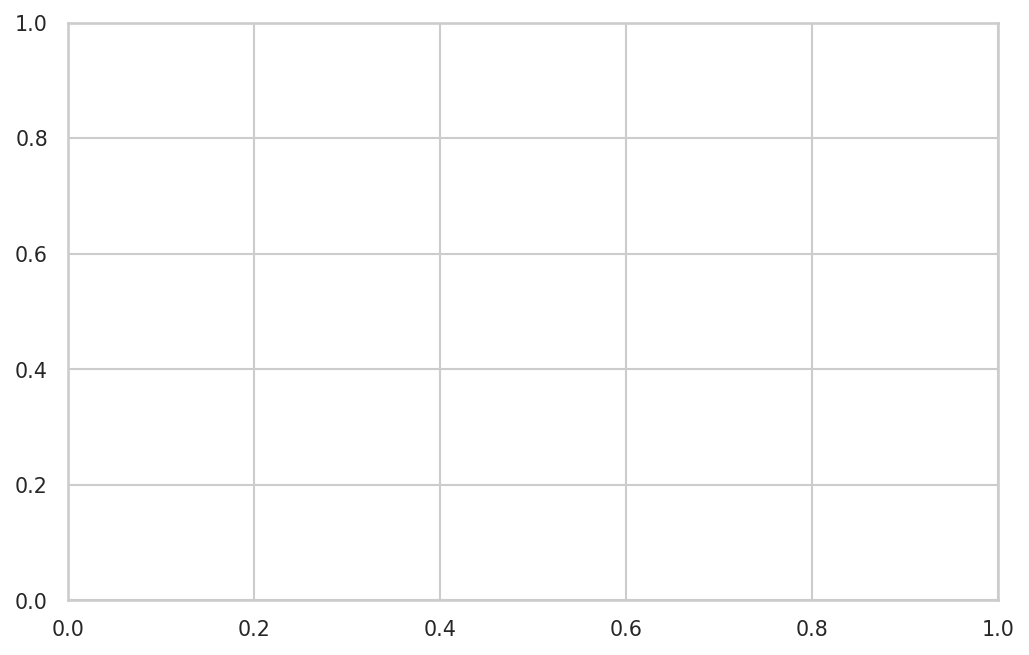

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set(style="whitegrid", palette="muted", font_scale=0.9)
plt.rcParams['figure.dpi'] = 150
csv_path = "hnsw_grid_search_results.csv"
df = pd.read_csv(csv_path)

display(df)

# Extract unique parameter values
Ms = sorted(df['M'].unique())
efcs = sorted(df['ef_construction'].unique())
efs = sorted(df['ef_search'].unique())

# 1) Build Time vs M in subplots by ef_construction
fig, axes = plt.subplots(len(efcs), 1, figsize=(8, 5*len(efcs)))
for ax, efc in zip(axes, efcs):
    subset = df[df['ef_construction'] == efc]
    sns.lineplot(data=subset, x='M', y='build_time_s', 
                 hue='ef_search', marker='o', ax=ax,
                 palette='viridis', legend='full')
    ax.set_title(f"Build Time vs M (ef_construction={efc})")
    ax.set_xlabel("M")
    ax.set_ylabel("Build Time (s)")
    ax.set_xticks(Ms)
    ax.legend(title='ef_search', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2) Query Performance in subplots
fig, axes = plt.subplots(len(efcs), 2, figsize=(12, 4*len(efcs)))
for row, efc in enumerate(efcs):
    subset = df[df['ef_construction'] == efc]
    # Query Time
    sns.lineplot(data=subset, x='M', y='avg_query_ms', hue='ef_search',
                 style='ef_search', markers=True, dashes=False, ax=axes[row, 0],
                 palette='cool', err_style='bars', errorbar='sd')
    axes[row, 0].set_title(f"Query Time vs M (ef_construction={efc})")
    axes[row, 0].set_yscale('log')
    
    # Recall
    sns.lineplot(data=subset, x='M', y='recall', hue='ef_search',
                 style='ef_search', markers=True, dashes=False, ax=axes[row, 1],
                 palette='hot', err_style='bars', errorbar='sd')
    axes[row, 1].set_title(f"Recall@10 vs M (ef_construction={efc})")
    axes[row, 1].set_ylim(0, 1.05)

    for ax in axes[row]:
        ax.set_xlabel("M")
        ax.set_xticks(Ms)
        ax.legend().remove()
        
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='ef_search', 
           bbox_to_anchor=(1.15, 0.5), loc='center')
plt.tight_layout()
plt.show()

# 3) Trade-off Scatter Plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Recall vs Query Time
sc1 = sns.scatterplot(data=df, x='avg_query_ms', y='recall', 
                      hue='M', size='ef_construction', 
                      palette='viridis', sizes=(40, 200), ax=ax[0])
ax[0].set_title("Recall@10 vs Query Time Trade-off")
ax[0].set_xlabel("Average Query Time (ms)")
ax[0].set_ylabel("Recall@10")

# Recall vs Build Time
sc2 = sns.scatterplot(data=df, x='build_time_s', y='recall', 
                      hue='ef_search', size='M', 
                      palette='plasma', sizes=(40, 200), ax=ax[1])
ax[1].set_title("Recall@10 vs Build Time Trade-off")
ax[1].set_xlabel("Build Time (s)")

for a in ax:
    a.grid(True, alpha=0.3)
    a.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 4) Enhanced Heatmaps
metrics = [
    ('recall', 'Recall@10', 'rocket_r'),
    ('avg_query_ms', 'Avg Query Time (ms)', 'viridis'),
    ('build_time_s', 'Build Time (s)', 'mako')
]

for metric, label, cmap in metrics:
    fig, axes = plt.subplots(1, len(efcs), figsize=(4*len(efcs), 4))
    if len(efcs) == 1: axes = [axes]
    
    for ax, efc in zip(axes, efcs):
        pivot = df[df['ef_construction'] == efc].pivot_table(
            values=metric, index='M', columns='ef_search')
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap,
                    cbar_kws={'label': label}, ax=ax)
        ax.set_title(f"{label} (ef_construction={efc})")
        ax.set_xlabel('ef_search')
        ax.set_ylabel('M')
    
    plt.tight_layout()
    plt.show()